# Imports

In [1]:
# Data analysis and manipulation libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
# Load the dataset from the local directory
data = pd.read_csv('../data/advertising_budget_and_sales.csv', index_col=0)

# Optionally rename columns
data.columns = ['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Sales']

# Display the first few rows of the dataset
print(data.head())
print(data.columns)

   TV Ad Budget  Radio Ad Budget  Newspaper Ad Budget  Sales
1         230.1             37.8                 69.2   22.1
2          44.5             39.3                 45.1   10.4
3          17.2             45.9                 69.3    9.3
4         151.5             41.3                 58.5   18.5
5         180.8             10.8                 58.4   12.9
Index(['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Sales'], dtype='object')


#### EDA
- Let's try to visualize how the information of each item is distributed and see the correlation between each of the items.

<function matplotlib.pyplot.show(close=None, block=None)>

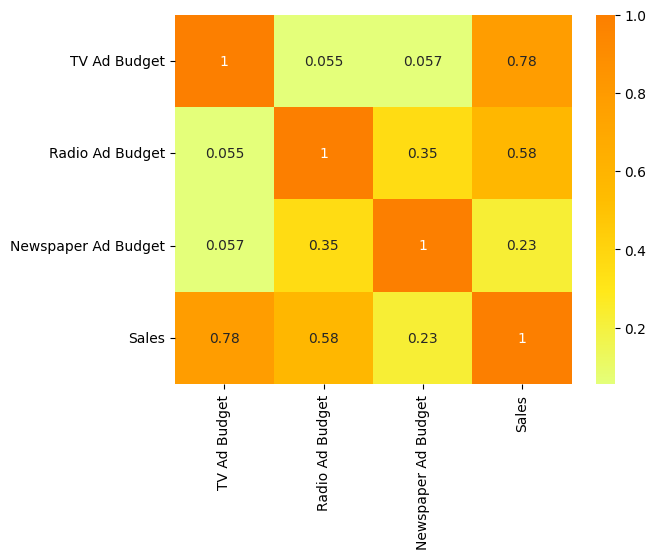

In [3]:
# Visualize the correlation between variables
sns.heatmap(data.corr(), cmap= 'Wistia', annot= True)
plt.show

#### Machine Learning Model

- Separating into training data and test data.

In [4]:
# Define features (X) and target variable (y)

y = data['Sales']
X = data.drop('Sales', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### We have a regression problem - Let's choose the models we are going to use:

- Linear Regression
- RandomForest (Decision Tree)

In [5]:
# Create regression models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor()

# training the AI
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor()

#### Testing the AI e choosing the best model.

- We're going to use the R² -> Tells us % that our model can explain what happens

In [6]:
# Make predictions
linear_predictions = linear_model.predict(X_test)
rf_predictions = random_forest_model.predict(X_test)

# Evaluate the models
print("R^2 Score (Linear Regression):", metrics.r2_score(y_test, linear_predictions))
print("R^2 Score (Random Forest):", metrics.r2_score(y_test, rf_predictions)) 

R^2 Score (Linear Regression): 0.8609466508230368
R^2 Score (Random Forest): 0.983264135205504


#### Graphic View of Forecasts

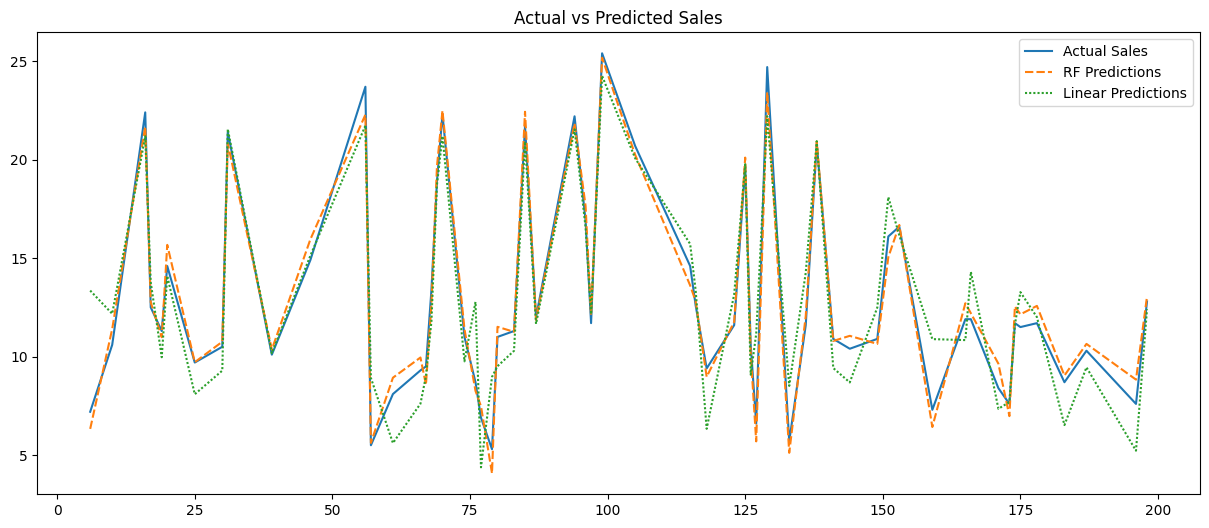

In [7]:
# Create a comparison DataFrame for predictions
comparison_df = pd.DataFrame()
comparison_df["Actual Sales"] = y_test
comparison_df["RF Predictions"] = rf_predictions
comparison_df["Linear Predictions"] = linear_predictions

# Visualize the predictions
plt.figure(figsize=(15, 6))
sns.lineplot(data=comparison_df)
plt.title('Actual vs Predicted Sales')
plt.show()

#### Comparative Chart

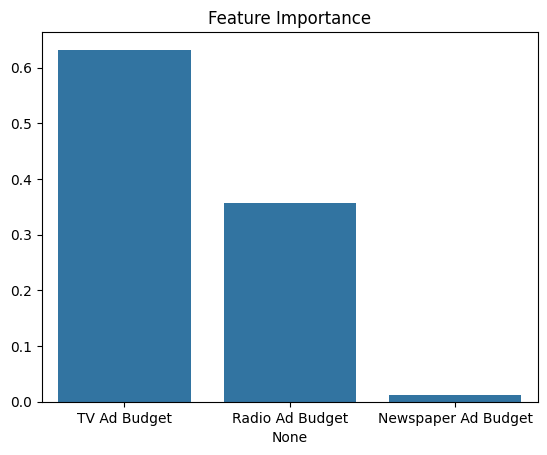

In [8]:
# Feature importance for Random Forest model
sns.barplot(x=X.columns, y=random_forest_model.feature_importances_)
plt.title('Feature Importance')
plt.show()

# new tests

In [27]:
# Load the dataset
data = pd.read_csv('../data/advertising_budget_and_sales.csv', index_col=0)

In [28]:
# Create 'Internet Ad Budget' as the average of 'TV Ad Budget' and 'Radio Ad Budget'
data['Internet Ad Budget ($)'] = (data['TV Ad Budget ($)'] + data['Radio Ad Budget ($)']) / 2

# Reorganizing columns to put 'Internet Ad Budget ($)' before 'Sales ($)'
data = data[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Internet Ad Budget ($)', 'Sales ($)']]

# Optionally rename columns
data.columns = ['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Internet Ad Budget', 'Sales']

# Display the first few rows of the dataset
print(data.head())
print(data.columns)

   TV Ad Budget  Radio Ad Budget  Newspaper Ad Budget  Internet Ad Budget  \
1         230.1             37.8                 69.2              133.95   
2          44.5             39.3                 45.1               41.90   
3          17.2             45.9                 69.3               31.55   
4         151.5             41.3                 58.5               96.40   
5         180.8             10.8                 58.4               95.80   

   Sales  
1   22.1  
2   10.4  
3    9.3  
4   18.5  
5   12.9  
Index(['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget',
       'Internet Ad Budget', 'Sales'],
      dtype='object')


In [29]:
# Define an impact factor for the Internet
impact_factor = 0.1  # por exemplo, cada dólar investido em Internet aumenta as vendas em $0.5

# Calculate new sales based on the Internet ad budget
data['Adjusted Sales'] = data['Sales'] + (data['Internet Ad Budget'] * impact_factor)

In [30]:
# Drop the original 'Sales' column to avoid confusion in the analysis
data = data.drop('Sales', axis=1)

In [31]:
# Visualizando as novas vendas
print(data[['Internet Ad Budget', 'Adjusted Sales']].head(10))

# Excluindo a coluna 'Sales' do DataFrame para manter a organização
#if 'Sales' in data.columns:
    #data = data.drop('Sales', axis=1)

    Internet Ad Budget  Adjusted Sales
1               133.95          35.495
2                41.90          14.590
3                31.55          12.455
4                96.40          28.140
5                95.80          22.480
6                28.80          10.080
7                45.15          16.315
8                69.90          20.190
9                 5.35           5.335
10              101.20          20.720


In [32]:
# Define features (X) and target variable (y)
y = data['Adjusted Sales']
X = data.drop('Adjusted Sales', axis=1)

In [33]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
# Creating the models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor()

# Training the models
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor()

In [35]:
# Making predictions
predictions_linear = linear_model.predict(X_test)
predictions_random_forest = random_forest_model.predict(X_test)

In [36]:
# Evaluating the models
print("R^2 Score (Linear Regression):", metrics.r2_score(y_test, predictions_linear))
print("R^2 Score (Random Forest):", metrics.r2_score(y_test, predictions_random_forest))

R^2 Score (Linear Regression): 0.9566459358700672
R^2 Score (Random Forest): 0.9886803729392517


In [37]:
# Preparing the auxiliary DataFrame for visualization
auxiliary_table = pd.DataFrame()
auxiliary_table["Actual Sales"] = y_test
auxiliary_table["Adjusted Sales"] = data.loc[y_test.index, 'Adjusted Sales']  # Incluindo Adjusted Sales
auxiliary_table["Predictions (Random Forest)"] = predictions_random_forest
auxiliary_table["Predictions (Linear Regression)"] = predictions_linear

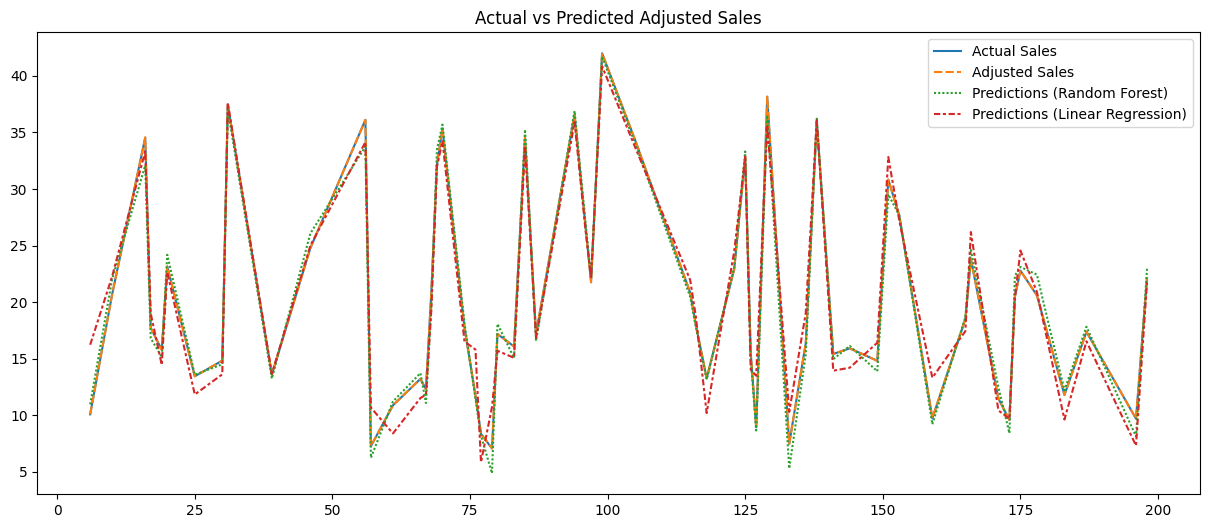

In [38]:
# Visualizing the predictions
plt.figure(figsize=(15, 6))
sns.lineplot(data=auxiliary_table)
plt.title('Actual vs Predicted Adjusted Sales')
plt.show()

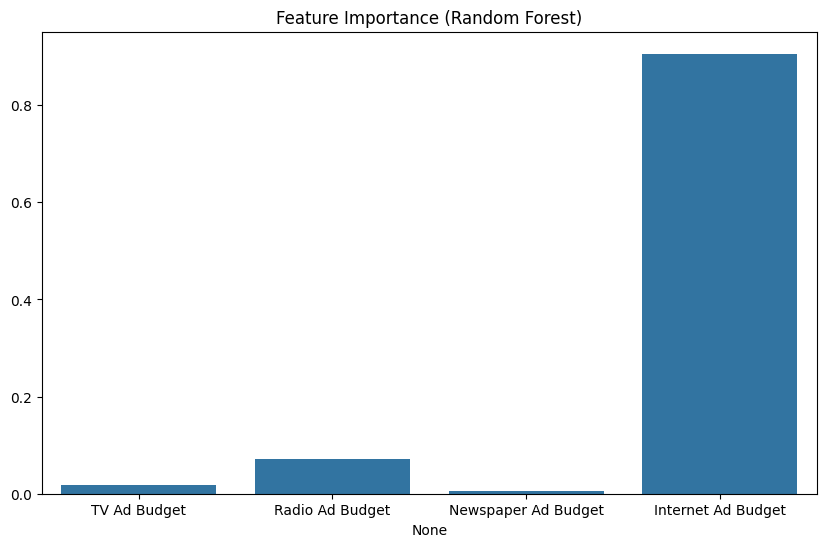

In [39]:
# Feature importance from Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=random_forest_model.feature_importances_)
plt.title('Feature Importance (Random Forest)')
plt.show()

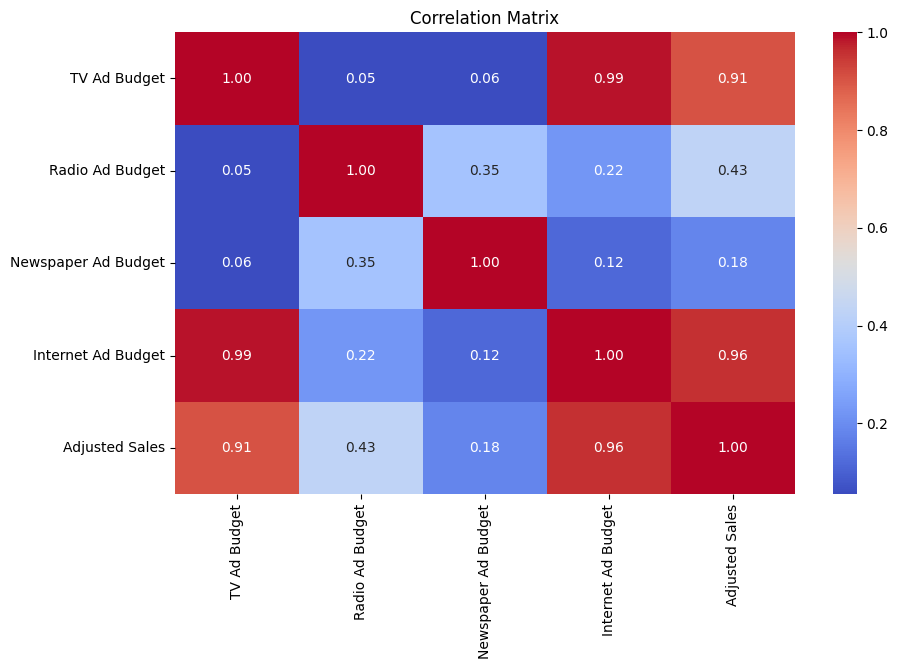

In [40]:

# Calculando a matriz de correlação
correlation_matrix = data.corr()

# Criando um heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

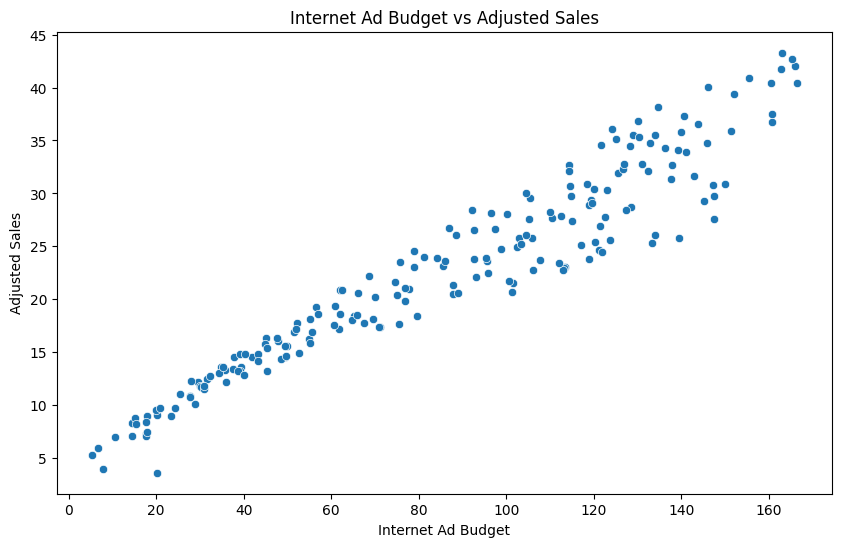

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Internet Ad Budget', y='Adjusted Sales')
plt.title('Internet Ad Budget vs Adjusted Sales')
plt.xlabel('Internet Ad Budget')
plt.ylabel('Adjusted Sales')
plt.show()

Linear Regression R² Score:
Training: 0.9697, Test: 0.9566
Cross-validation scores: [0.96373589 0.9733805  0.9784679  0.93867212 0.96856621]

Random Forest R² Score:
Training: 0.9982, Test: 0.9887
Cross-validation scores: [0.98945056 0.99163563 0.99126595 0.98207228 0.98302217]


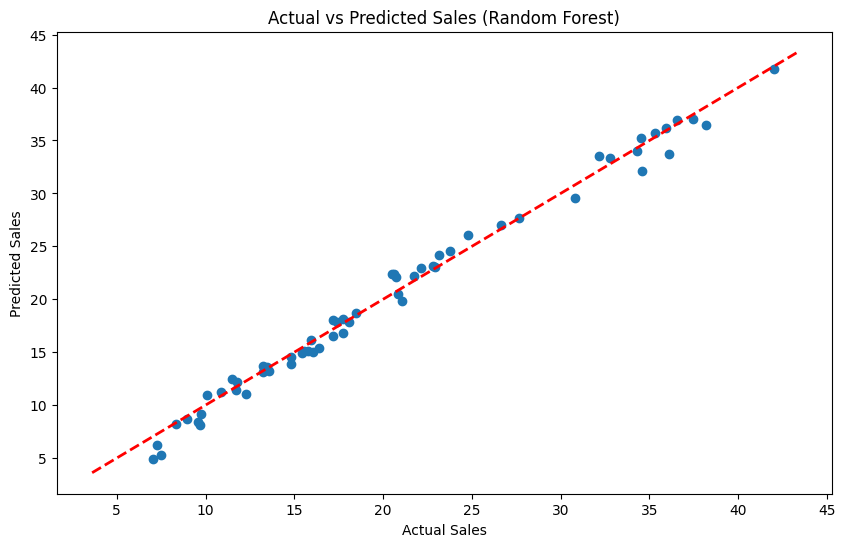

In [42]:
from sklearn.model_selection import cross_val_score

# Avaliando o desempenho do modelo de Linear Regression
linear_r2_train = linear_model.score(X_train, y_train)
linear_r2_test = linear_model.score(X_test, y_test)
linear_cv_scores = cross_val_score(linear_model, X, y, cv=5)

# Avaliando o desempenho do modelo de Random Forest
random_forest_r2_train = random_forest_model.score(X_train, y_train)
random_forest_r2_test = random_forest_model.score(X_test, y_test)
random_forest_cv_scores = cross_val_score(random_forest_model, X, y, cv=5)

# Resultados
print("Linear Regression R² Score:")
print(f"Training: {linear_r2_train:.4f}, Test: {linear_r2_test:.4f}")
print(f"Cross-validation scores: {linear_cv_scores}")

print("\nRandom Forest R² Score:")
print(f"Training: {random_forest_r2_train:.4f}, Test: {random_forest_r2_test:.4f}")
print(f"Cross-validation scores: {random_forest_cv_scores}")

# Visualizando Previsões vs Valores Reais para Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_random_forest)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Random Forest)')
plt.show()